In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter

plt.style.use('default')
sns.set(style="whitegrid")
%matplotlib inline

# Load data
df = pd.read_csv('data/e-shop_cleaned_final.csv')
session_df = pd.read_csv('data/e-shop_cleaned_final.csv')  # we'll create session level again if needed

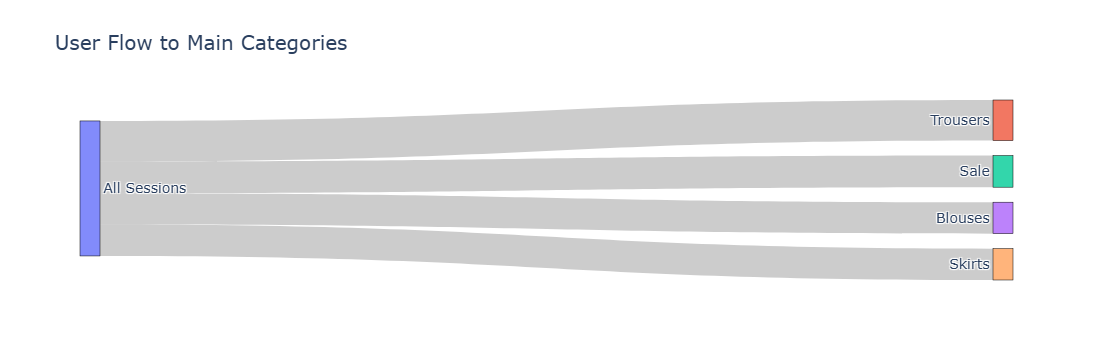

In [20]:
# Prepare data for Sankey (Top category flows)
cat_flow = df.groupby(['main_category_name']).size().reset_index(name='count')
top_cats = df['main_category_name'].value_counts().head(4).index.tolist()

# Simple Sankey: Source -> Main Category
labels = ['All Sessions'] + top_cats
source = [0] * len(top_cats)
target = list(range(1, len(top_cats)+1))
values = df['main_category_name'].value_counts().head(4).values

fig = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=20, line=dict(color="black", width=0.5),
              label=labels),
    link=dict(source=source, target=target, value=values)
)])

fig.update_layout(title_text="User Flow to Main Categories", font_size=14)
fig.show()

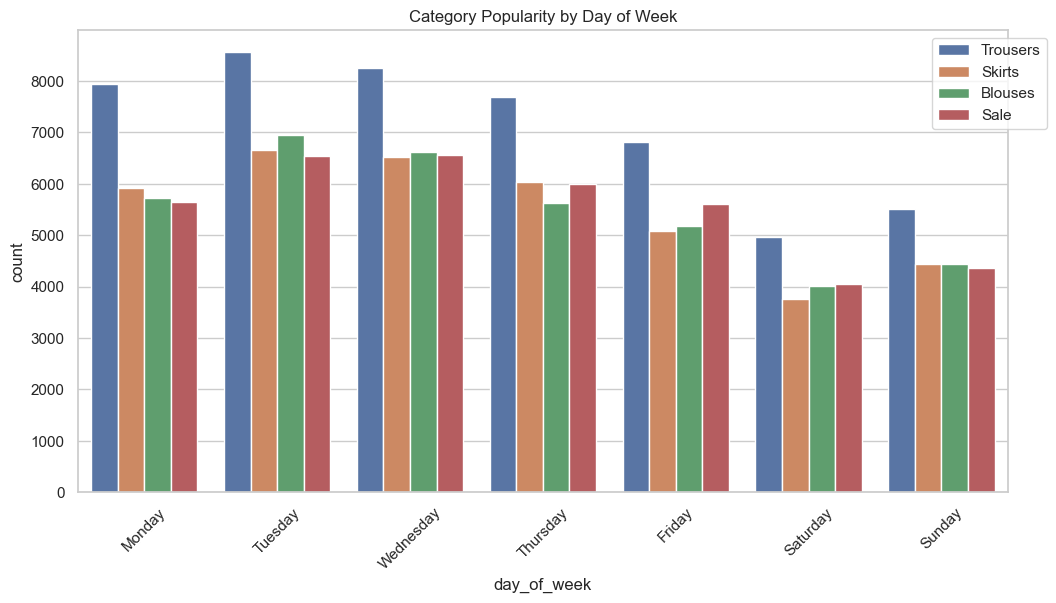

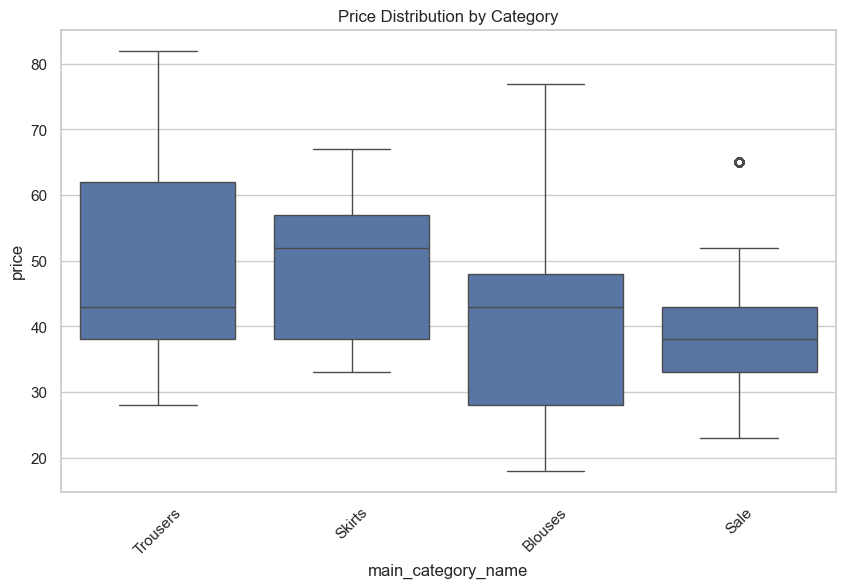

In [12]:
# Activity by Day of Week + Category
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='day_of_week', hue='main_category_name', 
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Category Popularity by Day of Week')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.savefig('visualizations/category_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

# Price Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='main_category_name', y='price')
plt.title('Price Distribution by Category')
plt.xticks(rotation=45)
plt.savefig('visualizations/distribution_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
print("KEY INSIGHTS FOR REPORT")

print("1. Dataset Overview:")
print(f"• Total sessions: {df['session_id'].nunique():,}")
print(f"• Total clicks: {len(df):,}")
print(f"• Average clicks per session: {len(df)/df['session_id'].nunique():.2f}")

print("\n2. Category Performance:")
print(df['main_category_name'].value_counts().head())

print("\n3. User Behavior:")
single_click = (df.groupby('session_id').size() == 1).sum()
print(f"• Bounce rate (1-click sessions): {single_click / df['session_id'].nunique() * 100:.1f}%")

# Add your own observations here

=== KEY INSIGHTS FOR REPORT ===
1. Dataset Overview:
• Total sessions: 24,026
• Total clicks: 165,474
• Average clicks per session: 6.89

2. Category Performance:
main_category_name
Trousers    49742
Sale        38747
Blouses     38577
Skirts      38408
Name: count, dtype: int64

3. User Behavior:
• Bounce rate (1-click sessions): 21.0%


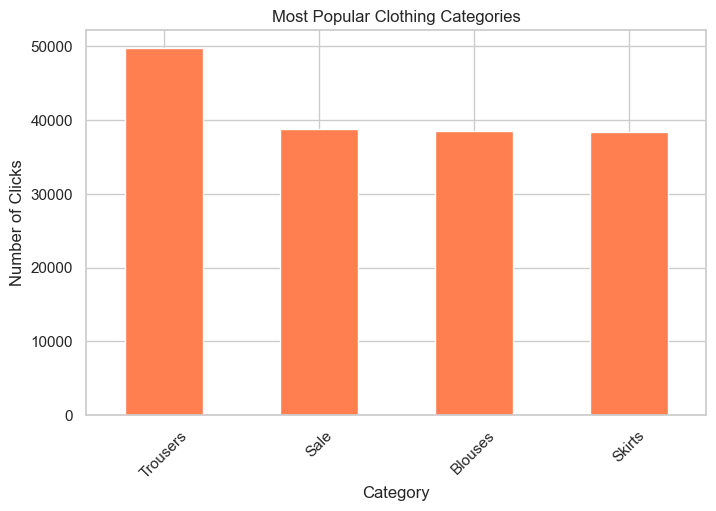

In [10]:
# 1. Category Distribution
plt.figure(figsize=(8,5))
df['main_category_name'].value_counts().plot(kind='bar', color='coral')
plt.title('Most Popular Clothing Categories')
plt.xlabel('Category')
plt.ylabel('Number of Clicks')
plt.xticks(rotation=45)
plt.savefig('visualizations/category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# ==================== RECREATE SESSION DATA ====================
session_df = df.groupby('session_id').agg(
    total_clicks=('order', 'count'),
    unique_categories=('main_category', 'nunique'),
    unique_products=('clothing_model', 'nunique'),
    total_price=('price', 'sum'),
    country=('country', 'first'),
    date=('date', 'first')
).reset_index()

print("✅ Session DataFrame created successfully!")
print(session_df.head())

✅ Session DataFrame created successfully!
   session_id  total_clicks  unique_categories  unique_products  total_price  \
0           1             9                  4                9          379   
1           2            10                  3                8          500   
2           3             6                  3                6          253   
3           4             4                  2                4          181   
4           5             1                  1                1           57   

   country        date  
0       29  2008-04-01  
1       29  2008-04-01  
2       21  2008-04-01  
3       21  2008-04-01  
4        9  2008-04-01  


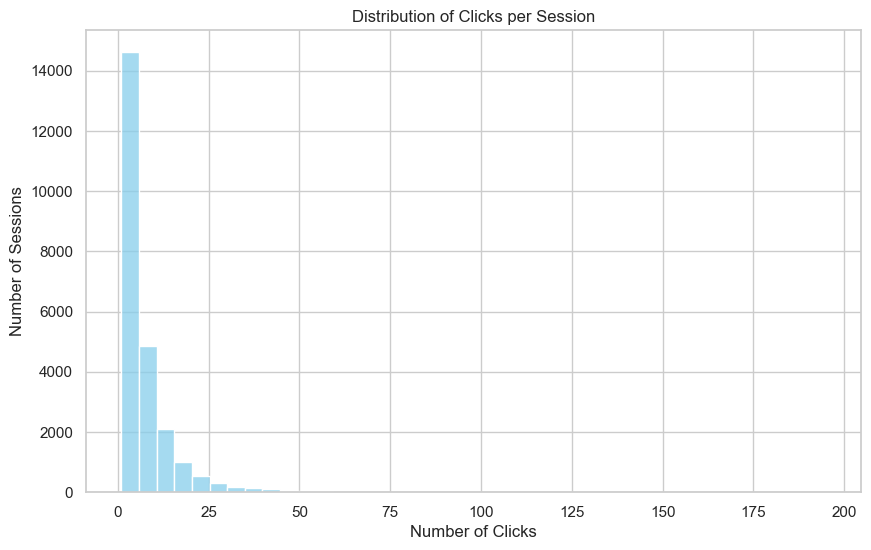

In [19]:
# 2. Clicks per Session
plt.figure(figsize=(10,6))
sns.histplot(data=session_df, x='total_clicks', bins=40, color='skyblue')
plt.title('Distribution of Clicks per Session')
plt.xlabel('Number of Clicks')
plt.ylabel('Number of Sessions')
plt.savefig('visualizations/clicks_per_session.png', dpi=300, bbox_inches='tight')
plt.show()

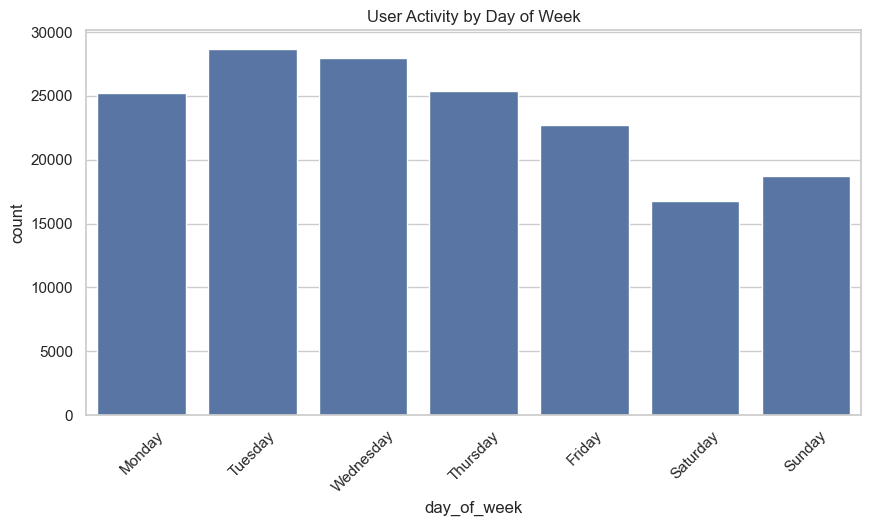

In [14]:
# 3. Activity by Day of Week
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='day_of_week', 
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('User Activity by Day of Week')
plt.xticks(rotation=45)
plt.savefig('visualizations/activity_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

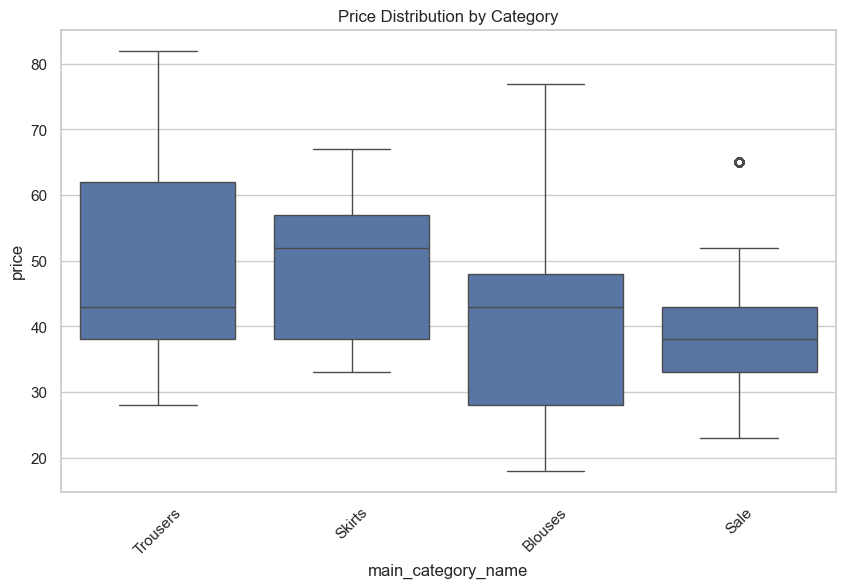

In [15]:
# 4. Price by Category (Boxplot)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='main_category_name', y='price')
plt.title('Price Distribution by Category')
plt.xticks(rotation=45)
plt.savefig('visualizations/price_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

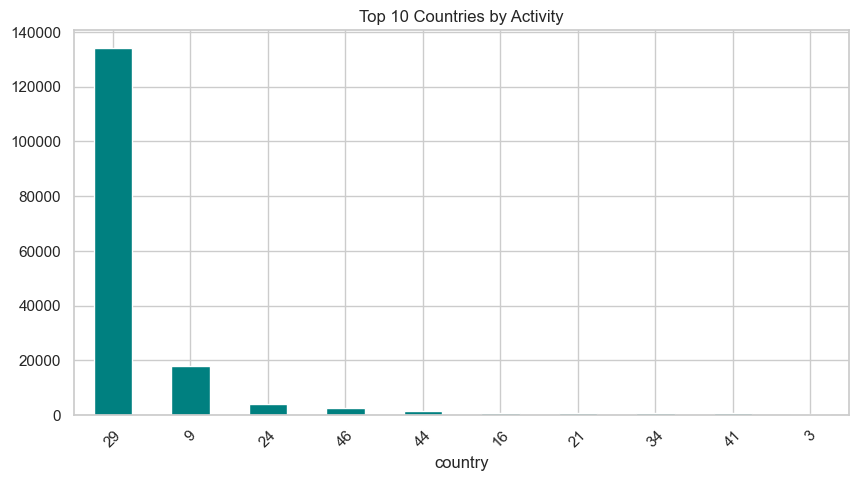

In [16]:
# 5. Top Countries
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Activity')
plt.xticks(rotation=45)
plt.savefig('visualizations/top_countries.png', dpi=300, bbox_inches='tight')
plt.show()